In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
train_dir="/content/drive/MyDrive/FACE_RAP001_K51"
img_width, img_height=100,100
batch_size=128
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
    )

In [7]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 1493 images belonging to 25 classes.


In [8]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(img_width,img_height,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(25,activation="softmax")
])

In [9]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,001 (6.62 MB)

 Trainable params: 1,735,001 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 405s 33s/step - accuracy: 0.0563 - loss: 3.2329
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.0824 - loss: 3.1398
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.1413 - loss: 2.9548
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.1815 - loss: 2.8578
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.2438 - loss: 2.6288
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.2639 - loss: 2.4651
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.3677 - loss: 2.1990
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.3476 - loss: 2.2236
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4233 - loss: 2.0042
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4334 - loss: 1.9186


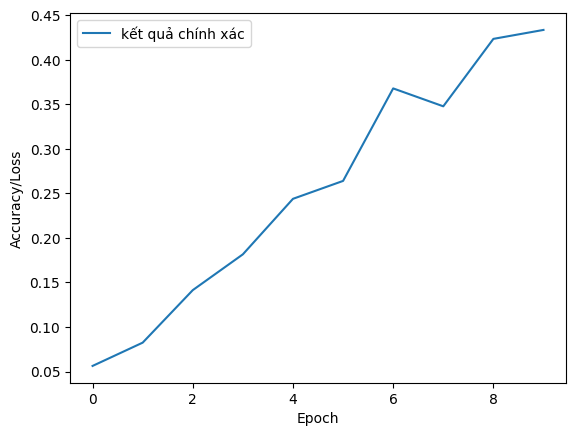

In [10]:
epochs=10
history=model.fit(train_generator,epochs=epochs)
plt.plot(history.history["accuracy"],label="kết quả chính xác")
plt.xlabel("Epoch")
plt.ylabel("Accuracy/Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


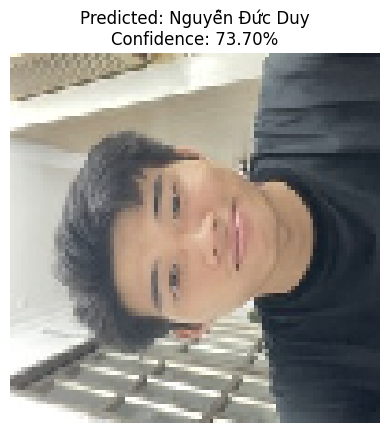

Người được nhận diện: Nguyễn Đức Duy
Độ tin cậy: 73.70%


In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/FACE_RAP001_K51/Nguyễn Đức Duy/IMG_8042.jpg"

img = image.load_img(img_path, target_size=(100,100))
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)

pred = model.predict(img_input)

class_names = list(train_generator.class_indices.keys())

predicted_class = np.argmax(pred)
predicted_name = class_names[predicted_class]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_name}\nConfidence: {confidence:.2f}%")
plt.show()

print("Người được nhận diện:", predicted_name)
print(f"Độ tin cậy: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


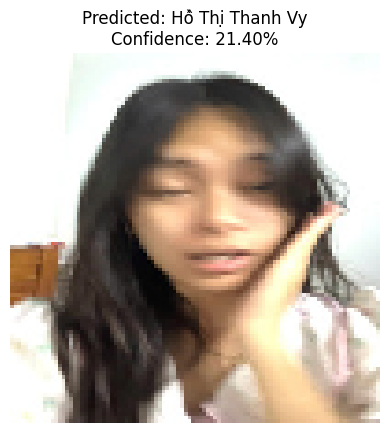

Người được nhận diện: Hồ Thị Thanh Vy
Độ tin cậy: 21.40%


In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/FACE_RAP001_K51/Hồ Thị Thanh Vy/1779203701513_503452852991551905_8421295955500906883_e1ea6cdd677dc8a0e791aaed2715cb46.jpg"

img = image.load_img(img_path, target_size=(100,100))
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)

pred = model.predict(img_input)

class_names = list(train_generator.class_indices.keys())

predicted_class = np.argmax(pred)
predicted_name = class_names[predicted_class]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_name}\nConfidence: {confidence:.2f}%")
plt.show()

print("Người được nhận diện:", predicted_name)
print(f"Độ tin cậy: {confidence:.2f}%")